<a href="https://colab.research.google.com/github/olumayowaadeniyi68-arch/AVCAD-EXERCISE/blob/main/Lesson6_Parameter_Estimation_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [13]:
# Load dataset

df = pd.read_csv(
    "EFIplus_medit.csv",
    sep=';'
)

df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [14]:
print(df.columns.tolist())

['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication', 'Organic_p

In [15]:
# Mean annual temperature

mean_temp = df['temp_ann'].mean()

print("Sample Mean:", mean_temp)

Sample Mean: 13.261950010328446


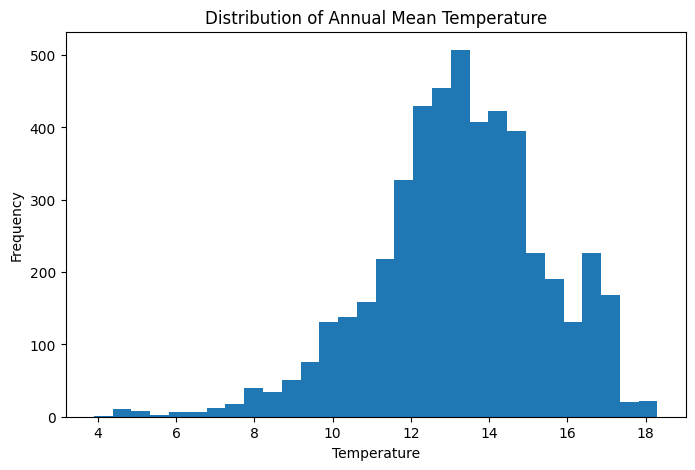

In [16]:
# Histogram of temperature

plt.figure(figsize=(8,5))

plt.hist(
    df['temp_ann'].dropna(),
    bins=30
)

plt.title("Distribution of Annual Mean Temperature")

plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

# MLE Interpretation

The sample mean estimates the average annual temperature in the dataset.

Under Maximum Likelihood Estimation (MLE), the sample mean is the parameter value that maximizes the likelihood of observing the data.

In [17]:
# Compute residuals

residuals = df['temp_ann'] - mean_temp

print(residuals.head())

0    4.33805
1   -3.96195
2   -3.16195
3   -3.16195
4   -2.96195
Name: temp_ann, dtype: float64


In [18]:
# Sum of squared errors

sse = np.sum(residuals ** 2)

print("Sum of Squared Errors:", sse)

Sum of Squared Errors: 22839.7311919025


# OLS Interpretation

Ordinary Least Squares minimizes the squared differences between observations and the estimated mean.

Smaller residuals indicate a better fit to the data.

In [19]:
# Bootstrap sample means

bootstrap_means = []

for i in range(1000):

    sample = df['temp_ann'].dropna().sample(
        n=500,
        replace=True
    )

    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

print(bootstrap_means[:10])

[13.3362 13.205  13.381  13.285  13.2618 13.2586 13.139  13.1218 13.3866
 13.1752]


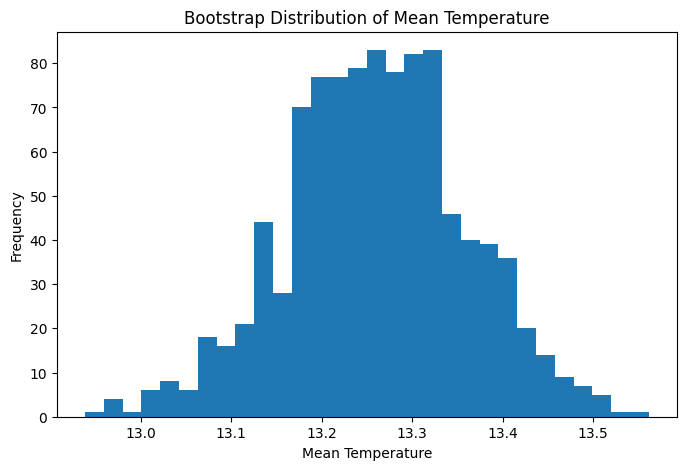

In [20]:
# Histogram of bootstrap means

plt.figure(figsize=(8,5))

plt.hist(bootstrap_means, bins=30)

plt.title("Bootstrap Distribution of Mean Temperature")

plt.xlabel("Mean Temperature")
plt.ylabel("Frequency")

plt.show()

In [21]:
# 95% confidence interval

lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

print("95% Confidence Interval:")
print(lower, upper)

95% Confidence Interval:
13.062365000000002 13.451425


# Bootstrap Interpretation

Bootstrap resampling repeatedly estimates the mean temperature using samples drawn with replacement.

The bootstrap distribution approximates the sampling distribution of the estimator and provides confidence intervals.

# Bayesian Estimation Interpretation

Bayesian estimation combines:
- prior knowledge
- observed data

to update beliefs about unknown parameters.

The posterior distribution reflects updated knowledge after observing the data.

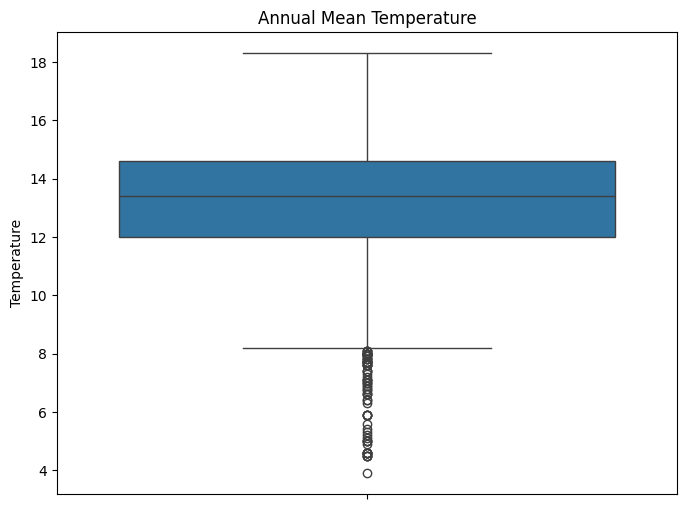

In [22]:
# Boxplot of temperature

plt.figure(figsize=(8,6))

sns.boxplot(
    y=df['temp_ann']
)

plt.title("Annual Mean Temperature")

plt.ylabel("Temperature")

plt.show()

# Final Conclusion

This analysis demonstrated several parameter estimation methods:

- Maximum Likelihood Estimation (MLE)
- Ordinary Least Squares (OLS)
- Bootstrap resampling
- Bayesian estimation concepts

The dataset was explored using summary statistics and visualizations to better understand annual mean temperature patterns.